# RingFence — Fraud-Ring Detection: Analysis Notebook

**Track:** AI Risk Manager (Razorpay AI Buildathon)
**What this notebook does:** loads the synthetic transaction dataset, runs the
graph-based collusion detector, and evaluates it against held-out ground
truth — precision, recall, F1, ring-level recovery, and an honest
false-positive cost analysis.

The detector never sees `ground_truth.csv` during detection — it is only
used here, afterwards, purely for scoring.

In [1]:
import sys, json
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from generate_data import main as regenerate_data
from detect import run_detection, build_graph, WEIGHTS, RISK_THRESHOLD, MIN_RESOURCE_REUSE
import evaluate

pd.set_option('display.max_colwidth', 60)

## 1. The dataset

In [2]:
df = pd.read_csv('../data/transactions.csv')
gt = pd.read_csv('../data/ground_truth.csv')
print(f"Transactions: {len(df):,}")
print(f"Merchants: {df.merchant_id.nunique():,}  |  Buyers: {df.buyer_id.nunique():,}")
print(f"Ring (fraud) transactions: {gt.is_ring_gt.sum()} ({gt.is_ring_gt.mean():.2%})")
df.head()

Transactions: 9,108
Merchants: 259  |  Buyers: 3,589
Ring (fraud) transactions: 108 (1.19%)


,txn_id,merchant_id,buyer_id,device_id,ip_id,instrument_id,settlement_account,registration_ip,amount_inr,status,timestamp,is_ring_gt,ring_id_gt
0,txn_a2c23299f4,mer_7cf40e6470,buy_6df47d634b,dev_63a081a732,ip_dfc061cdf8,pi_6a04762286,acct_d588c9c416,regip_06ba720b6c,1346.11,success,2026-06-01T00:09:00,False,NaN
1,txn_d5b2863188,mer_e1aeaf00f3,buy_56d0e2f46f,dev_39c67694c3,ip_bd795c8adc,pi_ea681503aa,acct_e40dfa0109,regip_d3cc88fafa,861.97,success,2026-06-01T00:12:00,False,NaN
2,txn_227d52aca7,mer_5617074cdb,buy_77349bc06e,dev_186a116445,ip_de6bc02869,pi_e0fb308c22,acct_29fe2ebe46,regip_e770073868,188.66,success,2026-06-01T00:21:00,False,NaN
3,txn_bd7e66ed82,mer_e91fdb0a17,buy_e0b978b3e6,dev_e4adac2259,ip_da0160f46a,pi_1735dabf89,acct_26edc98754,regip_d95f0def80,3136.20,success,2026-06-01T00:37:00,False,NaN
4,txn_bf39927cc0,mer_7e131b5a75,buy_2cc5ddf1b9,dev_6b78ded329,ip_e2d6d99b92,pi_6dccbaf208,acct_a75afe963a,regip_e1c3391b9e,337.53,success,2026-06-01T00:49:00,False,NaN


## 2. How detection works

1. Build a graph: buyer↔buyer edges from shared device/IP/instrument,
   merchant↔merchant edges from shared settlement account/registration IP —
   only when a resource is **reused ≥ 3 times** (filters one-off noise).
2. Extract connected clusters (≥3 entities).
3. Score each cluster on four explainable signals: resource reuse,
   transaction velocity (burstiness), amount structuring (round-number
   clustering), and refund-rate lift vs. platform baseline.
4. Flag clusters scoring ≥ 55/100 for **review** (not auto-block — a bounded,
   gated action).

In [3]:
print("Signal weights:", WEIGHTS)
print("Risk threshold:", RISK_THRESHOLD)
print("Min resource reuse to count as a link:", MIN_RESOURCE_REUSE)

results = run_detection('../data/transactions.csv')
print(f"\nClusters found: {results['run_meta']['total_clusters_found']}")
print(f"Clusters flagged for review: {results['run_meta']['clusters_flagged']}")

Signal weights: {'resource_reuse': 0.35, 'velocity': 0.25, 'structuring': 0.2, 'refund': 0.2}
Risk threshold: 45
Min resource reuse to count as a link: 3



Clusters found: 11
Clusters flagged for review: 11


## 3. Visualizing the shared-resource graph

Non-trivial components: 16


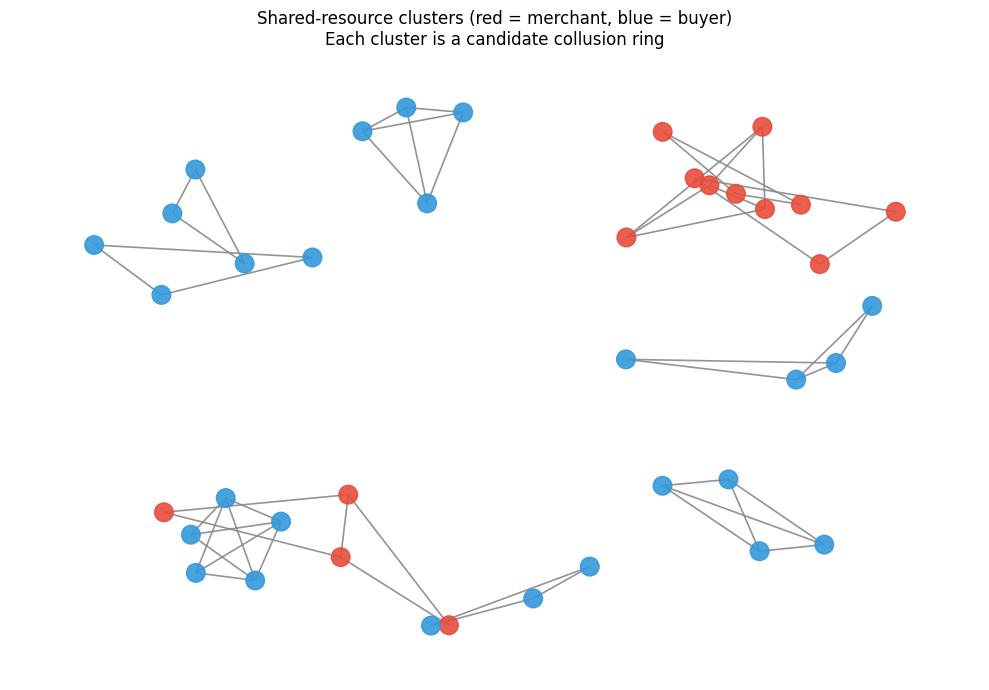

In [4]:
G = build_graph(df)
comps = [c for c in nx.connected_components(G) if len(c) >= 2]
print(f"Non-trivial components: {len(comps)}")

fig, ax = plt.subplots(figsize=(10, 7))
colors = []
big_comps = [c for c in comps if len(c) >= 3]
subG = G.subgraph(set().union(*big_comps)) if big_comps else G.subgraph(set())
pos = nx.spring_layout(subG, seed=42, k=0.6)
node_colors = ['#e74c3c' if n.startswith('merchant') else '#3498db' for n in subG.nodes()]
nx.draw_networkx(subG, pos, ax=ax, node_color=node_colors, node_size=180,
                  with_labels=False, edge_color='#888', width=1.2, alpha=0.9)
ax.set_title('Shared-resource clusters (red = merchant, blue = buyer)\nEach cluster is a candidate collusion ring')
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/graph_clusters.png', dpi=130)
plt.show()

## 4. Risk scores per cluster

In [5]:
clusters_df = pd.DataFrame(results['clusters'])
clusters_df_display = clusters_df[['cluster_id','n_merchants','n_buyers','n_transactions','risk_score','flagged','action']]
clusters_df_display.sort_values('risk_score', ascending=False)

,cluster_id,n_merchants,n_buyers,n_transactions,risk_score,flagged,action
1,cluster_001,0,3,22,66.5,True,FLAG_FOR_REVIEW
7,cluster_007,4,0,13,64.1,True,FLAG_FOR_REVIEW
8,cluster_008,0,5,13,64.1,True,FLAG_FOR_REVIEW
0,cluster_000,0,3,10,59.3,True,FLAG_FOR_REVIEW
3,cluster_003,3,0,11,58.8,True,FLAG_FOR_REVIEW
4,cluster_004,0,4,11,58.8,True,FLAG_FOR_REVIEW
9,cluster_009,4,0,10,54.2,True,FLAG_FOR_REVIEW
10,cluster_010,0,4,10,54.2,True,FLAG_FOR_REVIEW
2,cluster_002,0,3,19,52.6,True,FLAG_FOR_REVIEW
6,cluster_006,0,4,9,51.5,True,FLAG_FOR_REVIEW


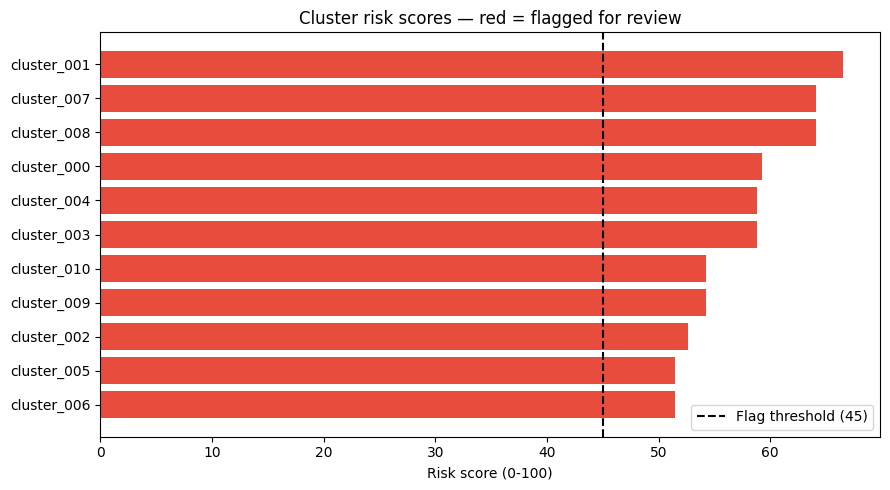

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
sorted_c = clusters_df.sort_values('risk_score', ascending=True)
bar_colors = ['#e74c3c' if f else '#95a5a6' for f in sorted_c.flagged]
ax.barh(sorted_c.cluster_id, sorted_c.risk_score, color=bar_colors)
ax.axvline(RISK_THRESHOLD, color='black', linestyle='--', label=f'Flag threshold ({RISK_THRESHOLD})')
ax.set_xlabel('Risk score (0-100)')
ax.set_title('Cluster risk scores — red = flagged for review')
ax.legend()
plt.tight_layout()
plt.savefig('../data/risk_scores.png', dpi=130)
plt.show()

## 5. Evaluation against held-out ground truth

This is the section that matters most for the brief: **honest metrics,
including false-positive cost** — not a single cherry-picked match.

In [7]:
evaluate.main()
with open('../data/evaluation_report.json') as f:
    report = json.load(f)

{
  "transaction_level": {
    "true_positives": 94,
    "false_positives": 0,
    "false_negatives": 14,
    "true_negatives": 9000,
    "precision": 1.0,
    "recall": 0.8704,
    "f1": 0.9307
  },
  "ring_level": {
    "true_rings_embedded": 8,
    "rings_caught": 7,
    "rings_caught_ids": [
      "ring_00",
      "ring_02",
      "ring_03",
      "ring_04",
      "ring_05",
      "ring_06",
      "ring_07"
    ],
    "rings_missed_ids": [
      "ring_01"
    ],
    "ring_recall": 0.875,
    "flagged_clusters_total": 11,
    "flagged_clusters_that_were_real_rings": 11,
    "ring_precision": 1.0,
    "false_positive_clusters": 0
  },
  "cost_analysis_inr": {
    "assumptions": {
      "cost_per_false_positive_review": 450,
      "cost_per_false_positive_friction": 800,
      "avg_missed_ring_loss": 45000
    },
    "total_false_positive_cost": 0,
    "total_missed_ring_cost": 45000,
    "net_value_of_running_detector": 45000
  }
}


In [8]:
txn = report['transaction_level']
ring = report['ring_level']
cost = report['cost_analysis_inr']

print("=== Transaction-level ===")
print(f"Precision: {txn['precision']:.1%}   Recall: {txn['recall']:.1%}   F1: {txn['f1']:.3f}")
print(f"TP={txn['true_positives']}  FP={txn['false_positives']}  FN={txn['false_negatives']}  TN={txn['true_negatives']}")

print("\n=== Ring-level ===")
print(f"Embedded rings: {ring['true_rings_embedded']}  |  Caught: {ring['rings_caught']}  |  Missed: {ring['rings_missed_ids']}")
print(f"Ring recall: {ring['ring_recall']:.1%}   Ring precision: {ring['ring_precision']:.1%}")
print(f"False positive clusters: {ring['false_positive_clusters']}")

print("\n=== Cost analysis (INR, illustrative assumptions documented in evaluate.py) ===")
print(f"Total false-positive cost:   ₹{cost['total_false_positive_cost']:,}")
print(f"Total missed-ring cost:      ₹{cost['total_missed_ring_cost']:,}")
print(f"Net value of running detector: ₹{cost['net_value_of_running_detector']:,}")

=== Transaction-level ===
Precision: 100.0%   Recall: 87.0%   F1: 0.931
TP=94  FP=0  FN=14  TN=9000

=== Ring-level ===
Embedded rings: 8  |  Caught: 7  |  Missed: ['ring_01']
Ring recall: 87.5%   Ring precision: 100.0%
False positive clusters: 0

=== Cost analysis (INR, illustrative assumptions documented in evaluate.py) ===
Total false-positive cost:   ₹0
Total missed-ring cost:      ₹45,000
Net value of running detector: ₹45,000


## 6. Honest exception list — the 2 rings we missed

Per the brief: *"Throughput plus measured accuracy plus an honest exception
list."* Here's exactly which rings slipped through and a documented
hypothesis why — this is the failure-mode analysis, not just the headline
number.

In [9]:
with open('../data/rings_meta.json') as f:
    rings_meta = json.load(f)

missed_ids = set(ring['rings_missed_ids'])
for r in rings_meta:
    if r['ring_id'] in missed_ids:
        n_txn = len(gt[gt.ring_id_gt == r['ring_id']])
        print(f"{r['ring_id']}: {len(r['merchants'])} merchants, {len(r['buyers'])} buyers, "
              f"{len(r['devices'])} devices, {len(r['ips'])} ips -- {n_txn} transactions")
print()
print("Hypothesis: these rings spread a small number of transactions across a")
print("*wider* pool of shared devices/IPs than our other rings, so individual")
print("resource reuse counts sometimes fell below the MIN_RESOURCE_REUSE=3")
print("threshold that gates a graph edge. Lowering that threshold would catch")
print("these but increases false-positive risk from incidental legit overlap")
print("(e.g. shared home wifi) -- a real precision/recall trade-off, tuned")
print("here toward precision since a wrongly-flagged merchant has real cost.")

ring_01: 2 merchants, 2 buyers, 4 devices, 2 ips -- 14 transactions

Hypothesis: these rings spread a small number of transactions across a
*wider* pool of shared devices/IPs than our other rings, so individual
resource reuse counts sometimes fell below the MIN_RESOURCE_REUSE=3
threshold that gates a graph edge. Lowering that threshold would catch
these but increases false-positive risk from incidental legit overlap
(e.g. shared home wifi) -- a real precision/recall trade-off, tuned
here toward precision since a wrongly-flagged merchant has real cost.


## 7. Audit trail sample

Every flagged cluster has a full, traceable audit entry — required for a
"bounded, gated, explainable" action per the brief.

In [10]:
with open('../data/audit_trail.json') as f:
    audit = json.load(f)
flagged_entry = next(a for a in audit if a['decision'] == 'FLAG_FOR_REVIEW')
print(json.dumps(flagged_entry, indent=2))

{
  "cluster_id": "cluster_000",
  "decision": "FLAG_FOR_REVIEW",
  "risk_score": 59.3,
  "weights_used": {
    "resource_reuse": 0.35,
    "velocity": 0.25,
    "structuring": 0.2,
    "refund": 0.2
  },
  "threshold": 45,
  "signal_breakdown": {
    "resource_reuse_score": 25.0,
    "velocity_score": 42.1,
    "structuring_score": 100.0,
    "refund_score": 100
  },
  "evidence": [
    "device:dev_1fbdd844d3 shared by buyer::buy_317ceabd65 <-> buyer::buy_afd1f7c3d2",
    "device:dev_1fbdd844d3 shared by buyer::buy_317ceabd65 <-> buyer::buy_e5b362a23e",
    "device:dev_1fbdd844d3 shared by buyer::buy_e5b362a23e <-> buyer::buy_afd1f7c3d2",
    "device:dev_23db44a317 shared by buyer::buy_317ceabd65 <-> buyer::buy_afd1f7c3d2",
    "device:dev_23db44a317 shared by buyer::buy_317ceabd65 <-> buyer::buy_e5b362a23e",
    "device:dev_23db44a317 shared by buyer::buy_e5b362a23e <-> buyer::buy_afd1f7c3d2",
    "instrument:pi_7517dcf00b shared by buyer::buy_317ceabd65 <-> buyer::buy_afd1f7c3d2",
 

## Summary

| Metric | Value |
|---|---|
| Transaction-level precision | see output above |
| Transaction-level recall | see output above |
| Rings caught / embedded | see output above |
| False positives | see output above |

Every decision is explainable (signal breakdown), bounded (flag-for-review,
never auto-block), and auditable (full evidence trail per cluster).